/run00059.mid.gz
Run description: modulo 0 sinstra (scrivania daq), palette sopra (test trigger)
DigitizerSamples: 1024
DigitizerPostTrg: 60
Saw a special event
Event # 0 of type ID 1 contains banks DIG0, DGH0
Received event with timestamp 1763452722 containing banks DIG0, DGH0
2025-11-18 07:58:42, banks DIG0, DGH0


/tmp/ipykernel_74108/3191224995.py:58: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  print("%s, banks %s" % (datetime.utcfromtimestamp(event.header.timestamp).strftime('%Y-%m-%d %H:%M:%S'), bank_names))


Event # 100 of type ID 1 contains banks DIG0, DGH0
Received event with timestamp 1763454722 containing banks DIG0, DGH0
2025-11-18 08:32:02, banks DIG0, DGH0


EOFError: Compressed file ended before the end-of-stream marker was reached

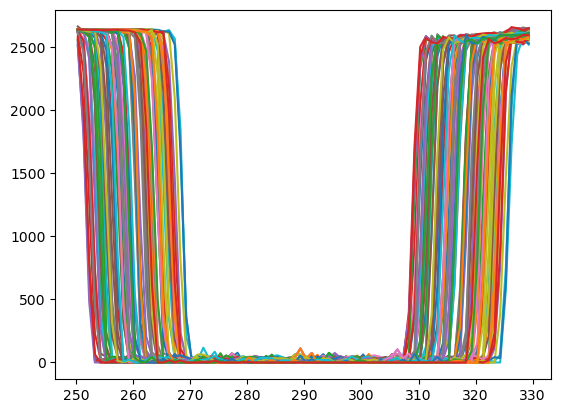

In [12]:
# === Import principali ===
import numpy as np
import matplotlib.pyplot as plt
import os
import midas.file_reader
from datetime import datetime
import wclib as wc

def plot_waveform(waveform, lenw, pmt, event_number, event_time):
    import numpy as np
    
    t = np.linspace(0,lenw, lenw)
    for ipmt in range(pmt):
        plt.subplot(pmt, 1, ipmt+1)
        plt.plot(t, waveform[ipmt])

    return

verbose = False
DEBUG   = False
SECTOR  = 2 # 0, 1, 2 
outplot = True # fa i plot
run     = 59
path    = '/home/daq/data/' 

mfile = wc.open_mid(run=run, path=path, cloud=False, tag='', verbose=verbose)

# esempio lettura informazioni dall'odb  #######
odb = wc.get_bor_odb(mfile)

try:
    Run_description   = odb.data['Experiment']['Run Parameters']['Run description']
    print('Run description:', Run_description)
except:
    print('WARNING: no run description')

DigitizerSamples  = odb.data['Configurations']['DigitizerSamples']
DigitizerPostTrg  = odb.data['Configurations']['DigitizerPostTrg']
print('DigitizerSamples:', DigitizerSamples)
print('DigitizerPostTrg:', DigitizerPostTrg)
corrected = odb.data['Configurations']['DRS4Correction']
channels_offset = odb.data['Configurations']['DigitizerOffset']
###############################################
# lettura equipment nel file #######
waveform_min1=[]
waveform_min2=[]
for event in mfile:
    if event.header.is_midas_internal_event():
        print("Saw a special event")
        continue

    bank_names = ", ".join(b.name for b in event.banks.values())
    event_number = event.header.serial_number
    event_time = datetime.fromtimestamp(event.header.timestamp).strftime('%Y-%m-%d %H:%M:%S')
    if verbose or event_number % 100==0:
        print("Event # %s of type ID %s contains banks %s" % (event_number, event.header.event_id, bank_names))
        print("Received event with timestamp %s containing banks %s" % (event.header.timestamp, bank_names))
        print("%s, banks %s" % (datetime.utcfromtimestamp(event.header.timestamp).strftime('%Y-%m-%d %H:%M:%S'), bank_names))

    for bank_name, bank in event.banks.items():
        if ('DGH0' in bank_name): # PMTs wavform 
            waveform_header = wc.daq_dgz_full2header(bank, verbose=False)
            if verbose: print (waveform_header)
            waveform = wc.daq_dgz_full2array(event.banks['DIG0'], waveform_header, verbose=False, ch_offset=channels_offset)
            len_waveform = waveform_header[2][0]
            # ch 8 trigger, ch1 Tr up, ch2 Tr down, ch 3 right, ch 4 left (from PMP PS)
            waveform_min1.append(np.min(waveform[0])) 
            waveform_min2.append(np.min(waveform[1]))
            plt.plot(np.linspace(0,len_waveform, len_waveform)[250:330], waveform[8][250:330])
            if DEBUG:
                plot_waveform(waveform, len_waveform, 8, event_number, event_time)
                plt.show()
    if DEBUG:        
        if event.header.serial_number == 20: # si ferm dopo i primi 20 eventi
            break
plt.show()
print('DONE')


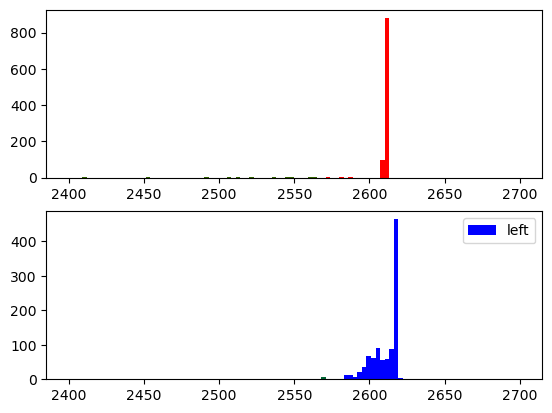

20 20


In [3]:
waveform_min1=np.array(waveform_min1)
waveform_min2=np.array(waveform_min2)
fig, ax=plt.subplots(2)
lrange=2400
rcut= 2570
lcut=2600
ax[0].hist(waveform_min1, bins=100, range=(lrange,2700), color='r', label='right')
ax[0].hist(waveform_min1[waveform_min1<rcut], bins=100, range=(lrange,2700), color='g', alpha=0.8)
ax[1].hist(waveform_min2, bins=100, range=(lrange,2700), color='b', label='left')
ax[1].hist(waveform_min2[waveform_min2<2580], bins=100, range=(lrange,2700), color='g', alpha=0.8)
plt.legend()
plt.show()
print(len(waveform_min1[waveform_min1<2570]), len(waveform_min2[waveform_min2<2580]))

In [86]:
len(waveform_min1[waveform_min1<2560])

636